Plots measuring the circulation of the vortex rings.

Plots that will be shown:

* injection length against circulation
* velocity against circulation - if I have good results for this.
* for the same injection conditions varying the rotation rate
* peak circulation vs rotation rate
* peak circulaiton vs time to peak
* peak vorticity against time
* vertical and horizontal sums of circulation to show density in comparison to peak vorticcity against time

Circulation calculated is 1D $\therefore$ I can add the second dimension of the number of cases

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()


# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
# h5file.close()

Circulation = np.zeros([7, u.shape[0]])
# Circulation = np.zeros([u.shape[0]])

rpms = [0, 1, 2, 3, 6, 9, 12]
Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

for i in range(len(rpms)):
# for i in range(3):
    # vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
    vels = h5file['Narrow']['U100']['L50'][f'RPM{rpms[i]}']
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    print(rpms[i])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

C:/Coding/Code
/Users/olliejackson/Coding
Thesis plot settings applied
0
1
2
3
6
9
12


Create the plot for different rotation rates:

5050 gives the best result i would say

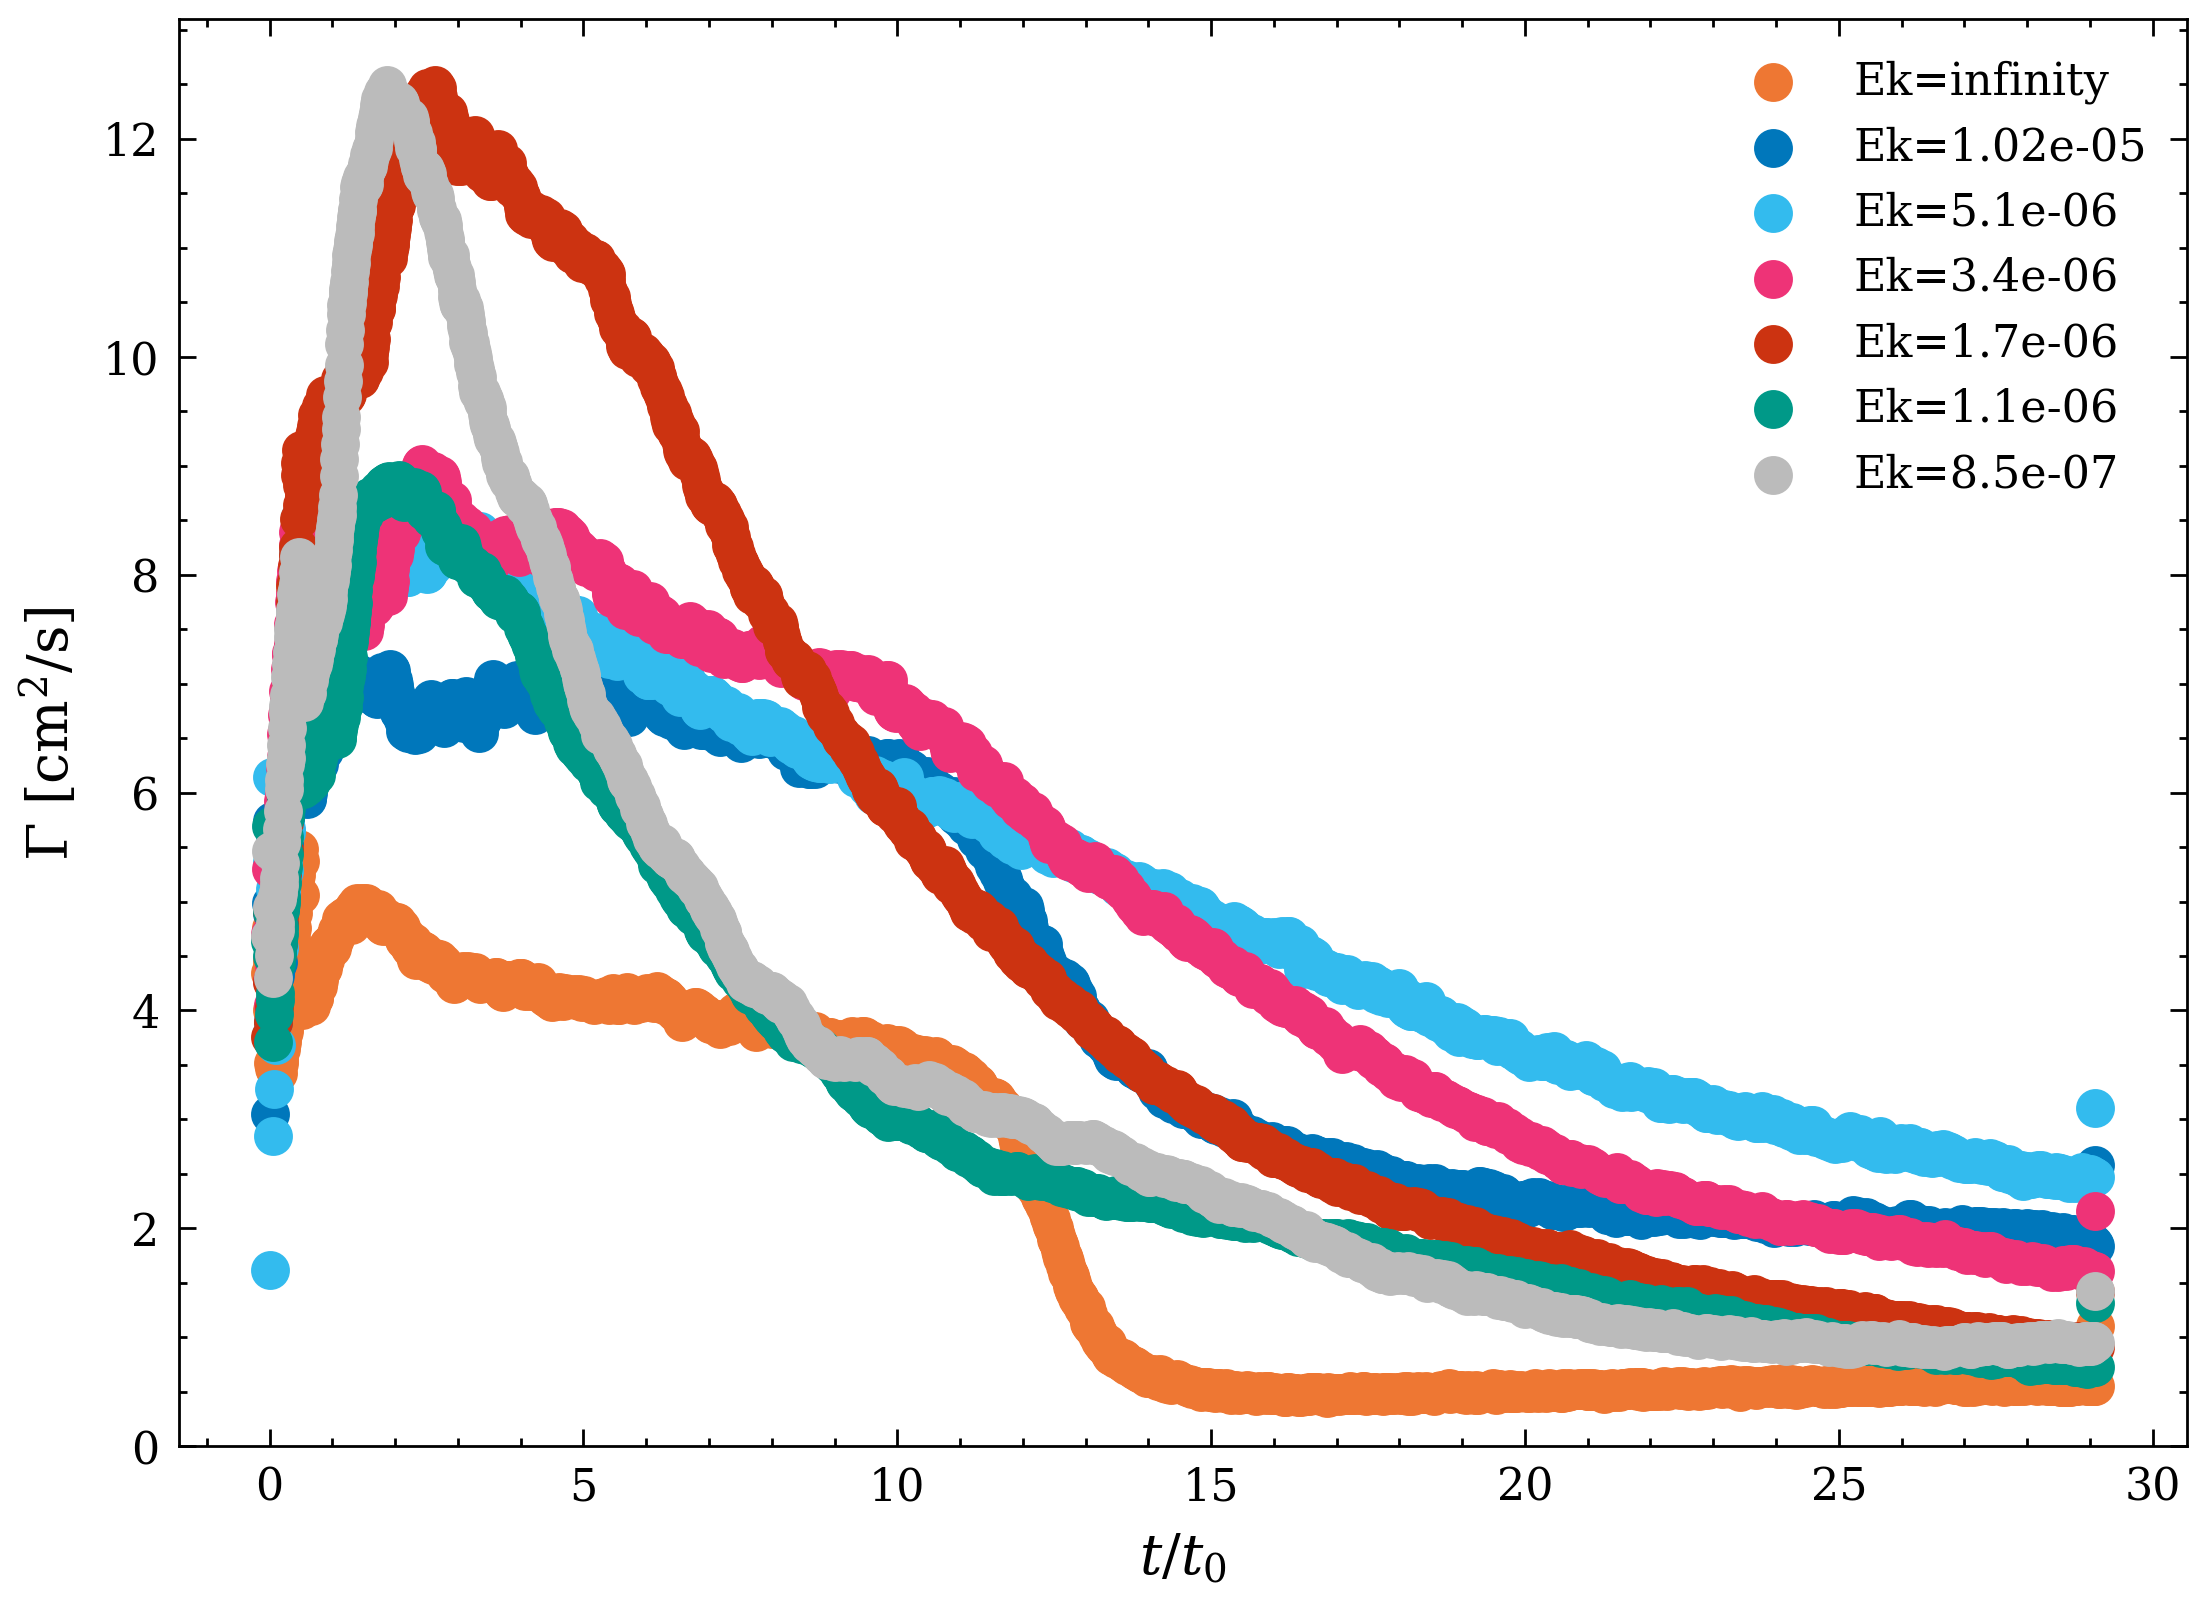

In [2]:
start_frame = 81
end_frame = 1891

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(7):
    # ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='Ek={}'.format(Eks[i]))
    ax.scatter(Time[start_frame:]-8/9, Circulation[i, start_frame:]-1, label='Ek={}'.format(Eks[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

For different rotation rates, plot the peak circulation, and the time to peak circulation.

this doesn't work in ekman for the non-rotating case obviously.

Plots:
* Peak $\Gamma$ against time
* Time to peak $\Gamma$ against ro - I can then do it for other conditions

$\Omega = rpm/60 \times 2 \times \Pi$

[0.         0.10471976 0.20943951 0.31415927 0.62831853 0.9424778
 1.25663706]
0.0
1.0
0.19272315135762316
0.10663731541871764
0.07371168224916111
0.03826617312159579


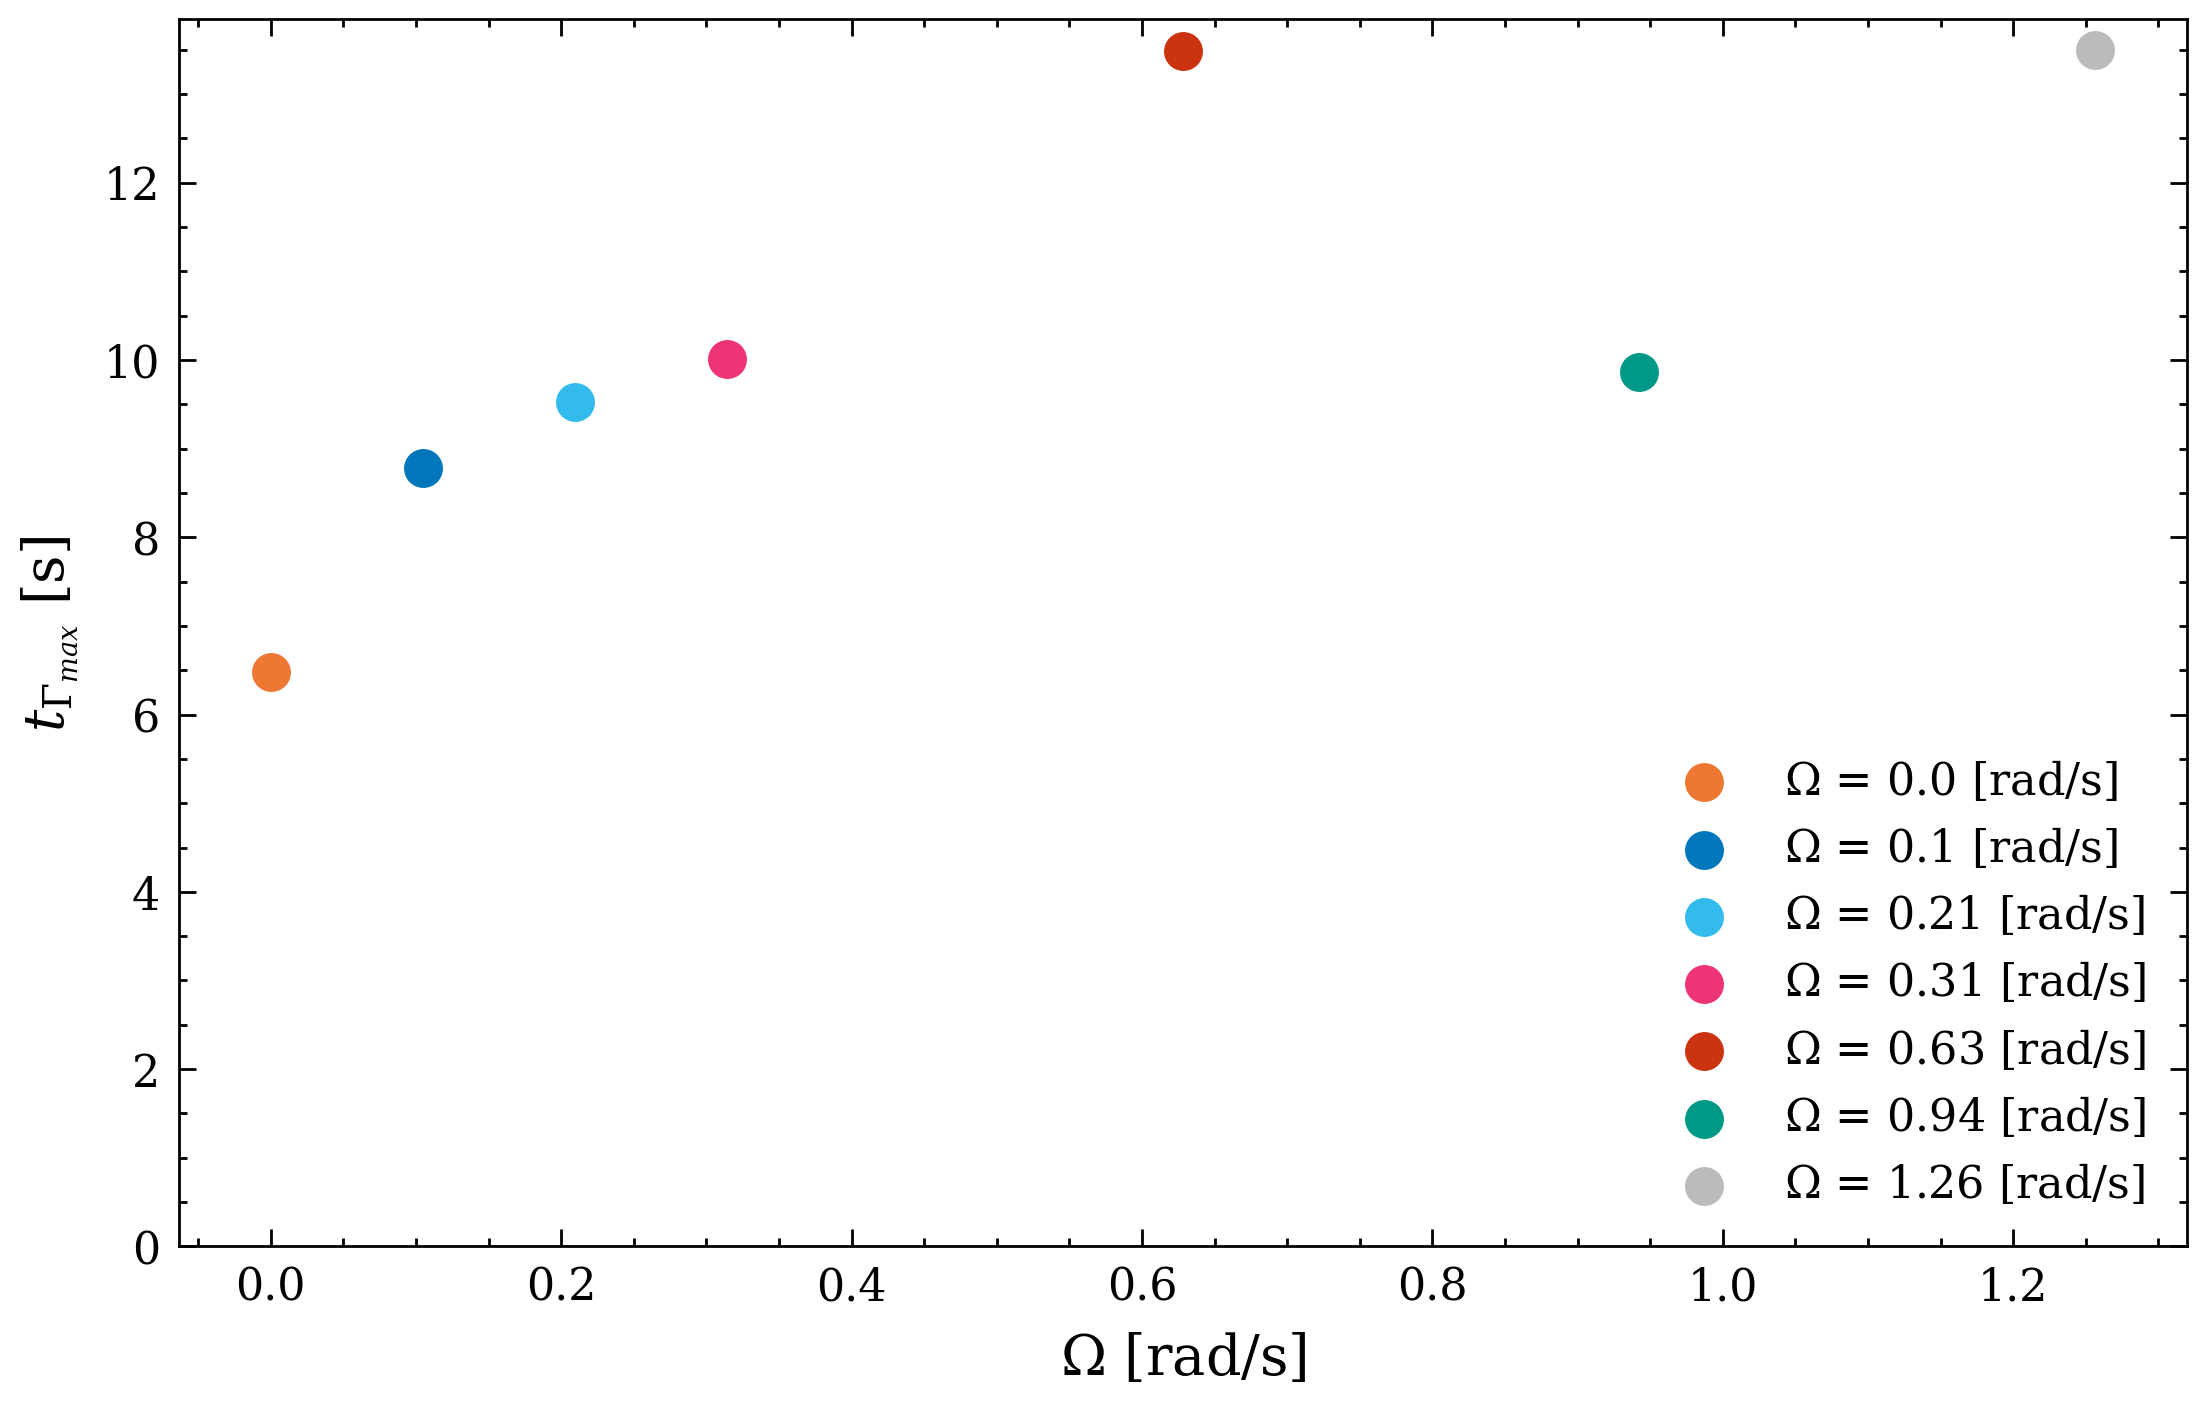

In [3]:
revs = [0, 1, 2, 3, 6, 9, 12]
Rossby = np.zeros([7])
u0 = 0.05
Omega = np.zeros([7])
Omega = 2*np.pi*np.array(revs)/60
print(Omega)


for i in range(6):
    Rossby[i+1] = u0 / (2 * revs[i]/60 * 2*np.pi + 0.05)
    print(Rossby[i])


fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax.scatter(0, Circulation[0,200], label=r'Ro = $\infty$', marker='x')
for i in range(7):
    # ax.scatter(Rossby[i], ([Circulation[i,200]]), label='Ro = {}'.format(round(Rossby[i], 2)))
    ax.scatter(Omega[i], (np.max([Circulation[i,:]])), label=r'$\Omega$ = {} [rad/s]'.format(round(Omega[i], 2)))
    # ax.scatter(Omega[i], (np.argmax([Circulation[i,:]]))/90, label=r'$\Omega$ = {} [rad/s]'.format(round(Omega[i], 2)))

ax.set_xlabel(r'$\Omega$ [rad/s]')
ax.set_ylabel(r'$t_{\Gamma_{max}}$ [s]')
ax.set_ylim(0)
plt.legend(fontsize=8, loc = 'lower right')

Different Injection lengths:

In [4]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
# h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/LengthTest.h5', 'r')

# lens = [50, 100]
lens = [25, 50, 75, 100, 125, 150, 175, 200, 225, 240]
Circulation = np.zeros([len(lens), u.shape[0]])


for i in range(len(lens)):
    print(lens[i])
    vels = h5file['Narrow']['U100']['L{}'.format(lens[i])]['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

25
50
75
100
125
150
175
200
225
240


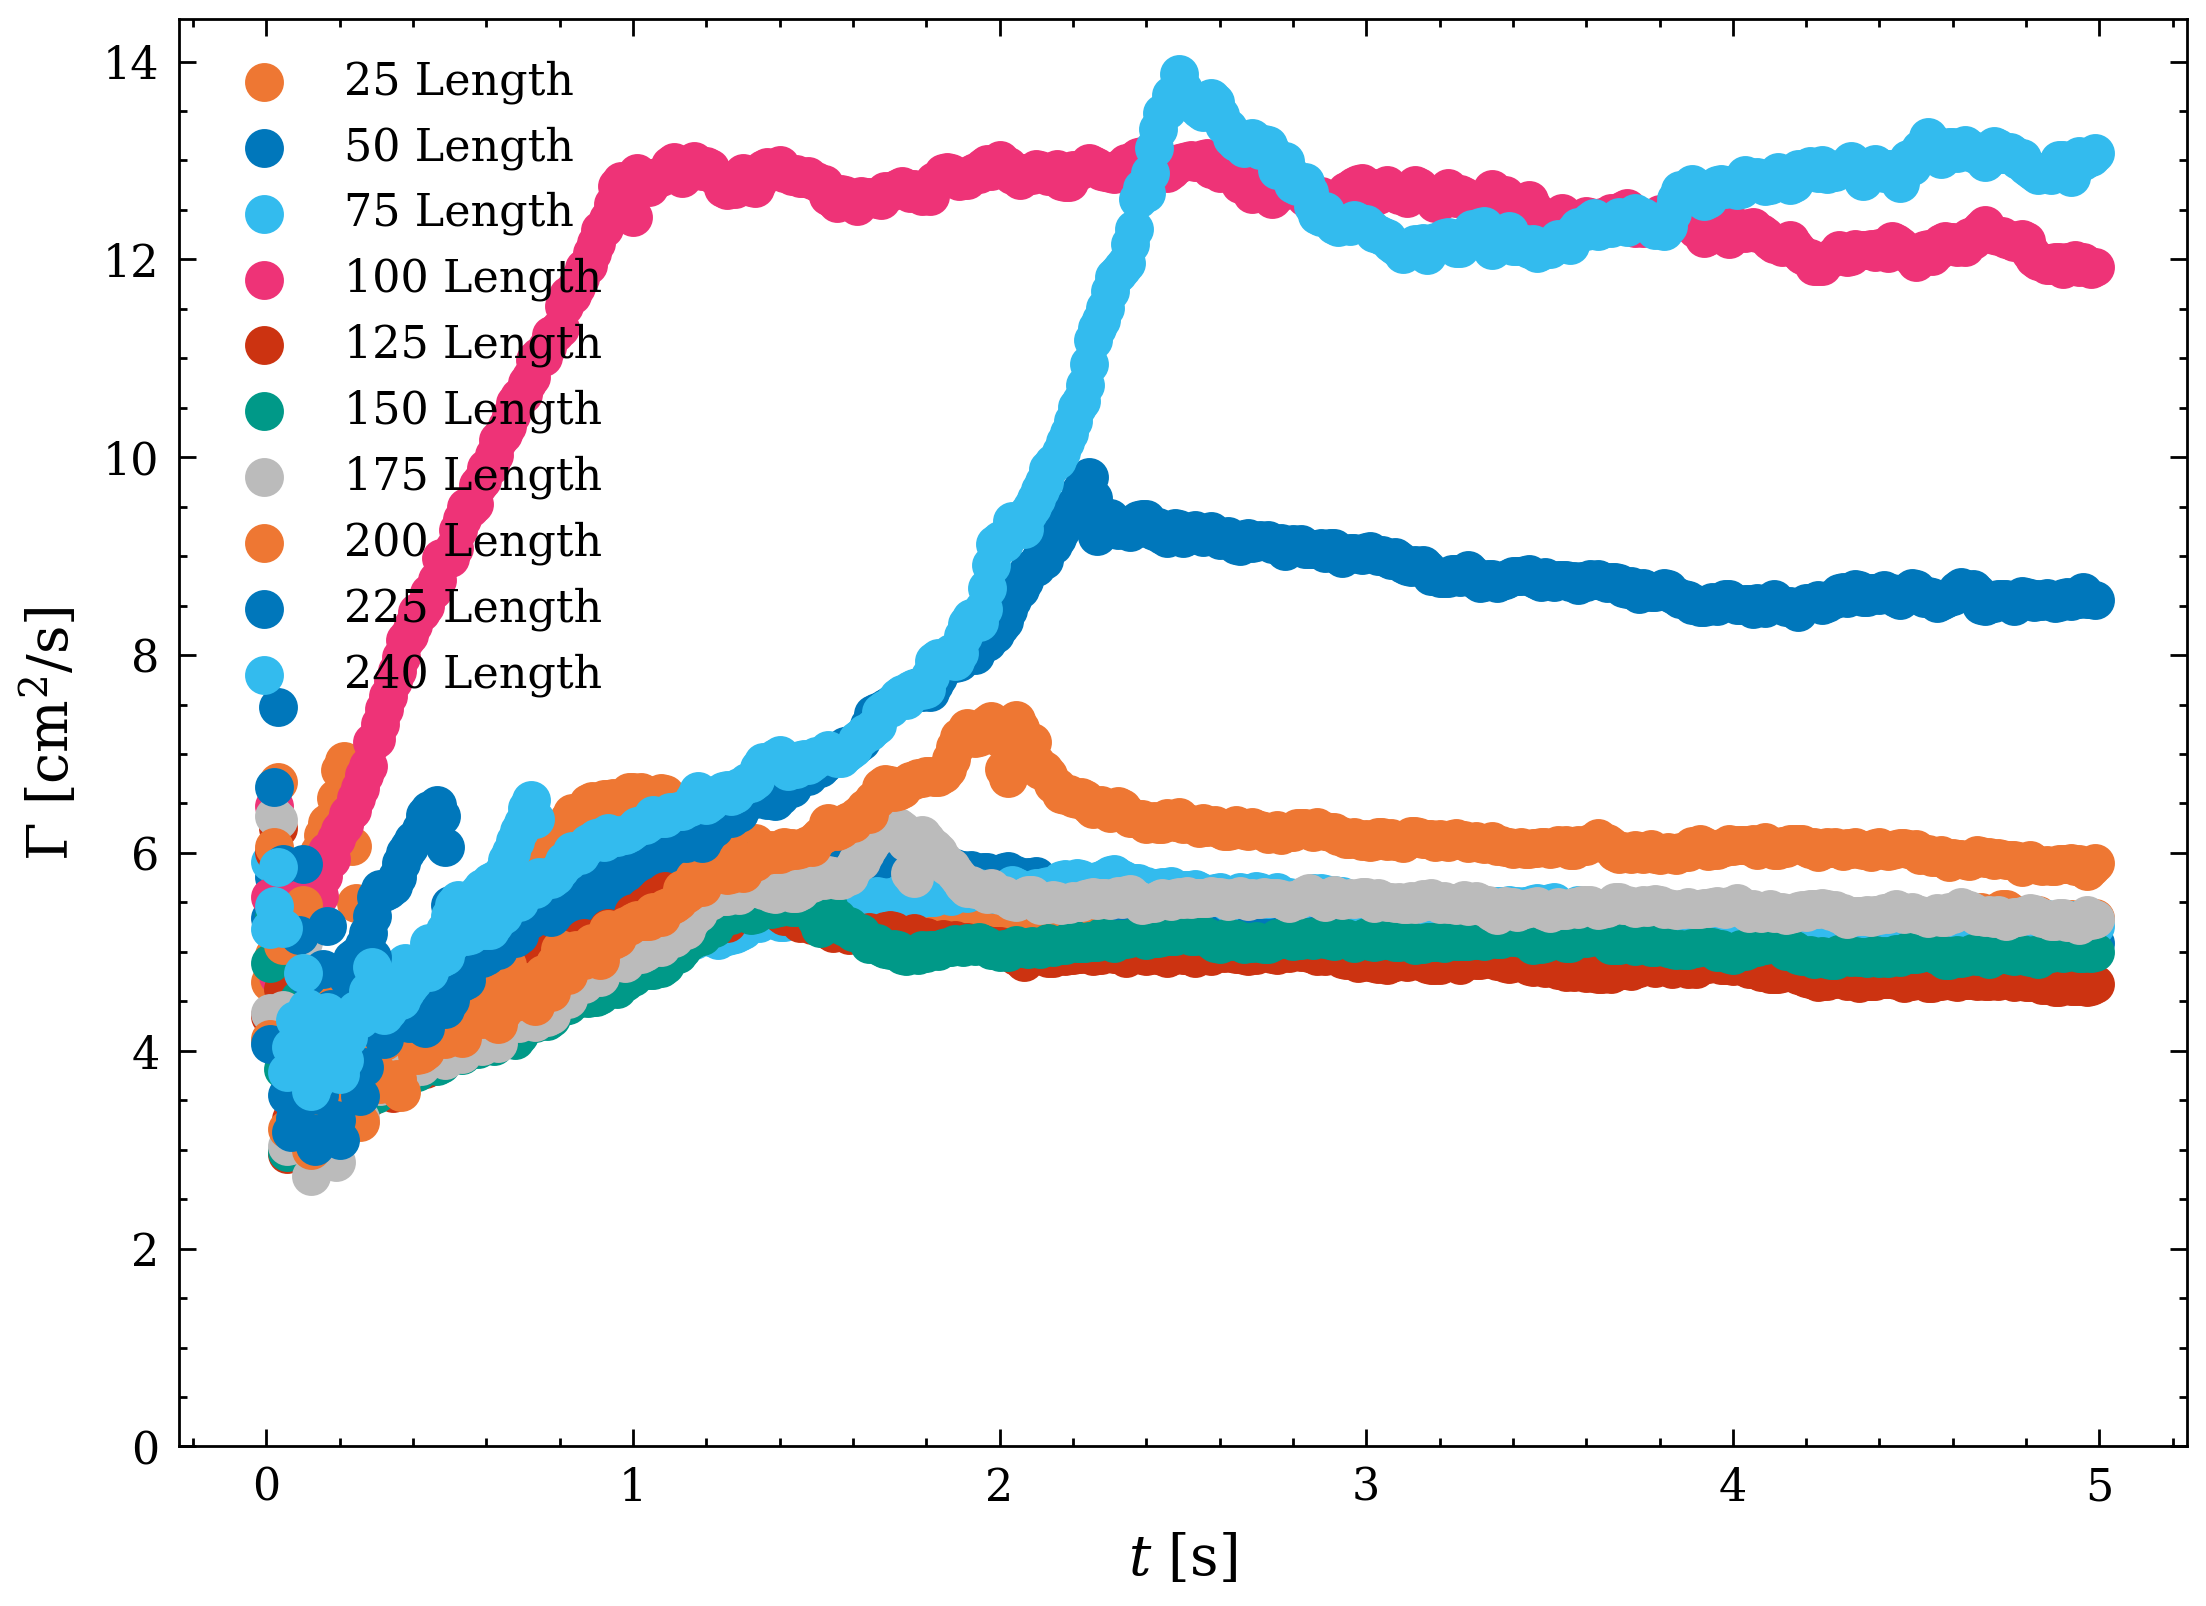

In [5]:
start_frame = 81
end_frame = 530

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(len(lens)):
    ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='{} Length'.format(lens[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

Section to look at the peak $\omega_{z}$ against time as per Verzicco and Gan

In [6]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLS.h5', 'r')

vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
# u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
# u, v = u/0.1, v/0.1 
# r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
# Time = oj.frames_to_seconds(u, v, 90)
# h5file.close()

Circulation = np.zeros([7, u.shape[0]])
# Circulation = np.zeros([u.shape[0]])
vort = np.zeros([7, u.shape[0], u.shape[1], u.shape[2]])
vort_gauss = np.zeros([7, u.shape[0], u.shape[1], u.shape[2]])

rpms = [0, 1, 2, 3, 6, 9, 12]
# rpms = [6, 9, 12]
for i in range(len(rpms)):
# for i in range(3):

    vels = h5file['Narrow']['U100']['L100']['RPM{}'.format(rpms[i])]
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    vort[i,:,:,:], vort_gauss[i,:,:,:] = oj.calculate_vorticity(u, v)
    print(rpms[i])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

0
1
2
3
6
9
12


/var/folders/3b/wm5n0kv12hbfldn7fhkv1d280000gn/T/ipykernel_34599/1167628249.py:2: RuntimeWarning: divide by zero encountered in true_divide
  scaling = 1/Time**3


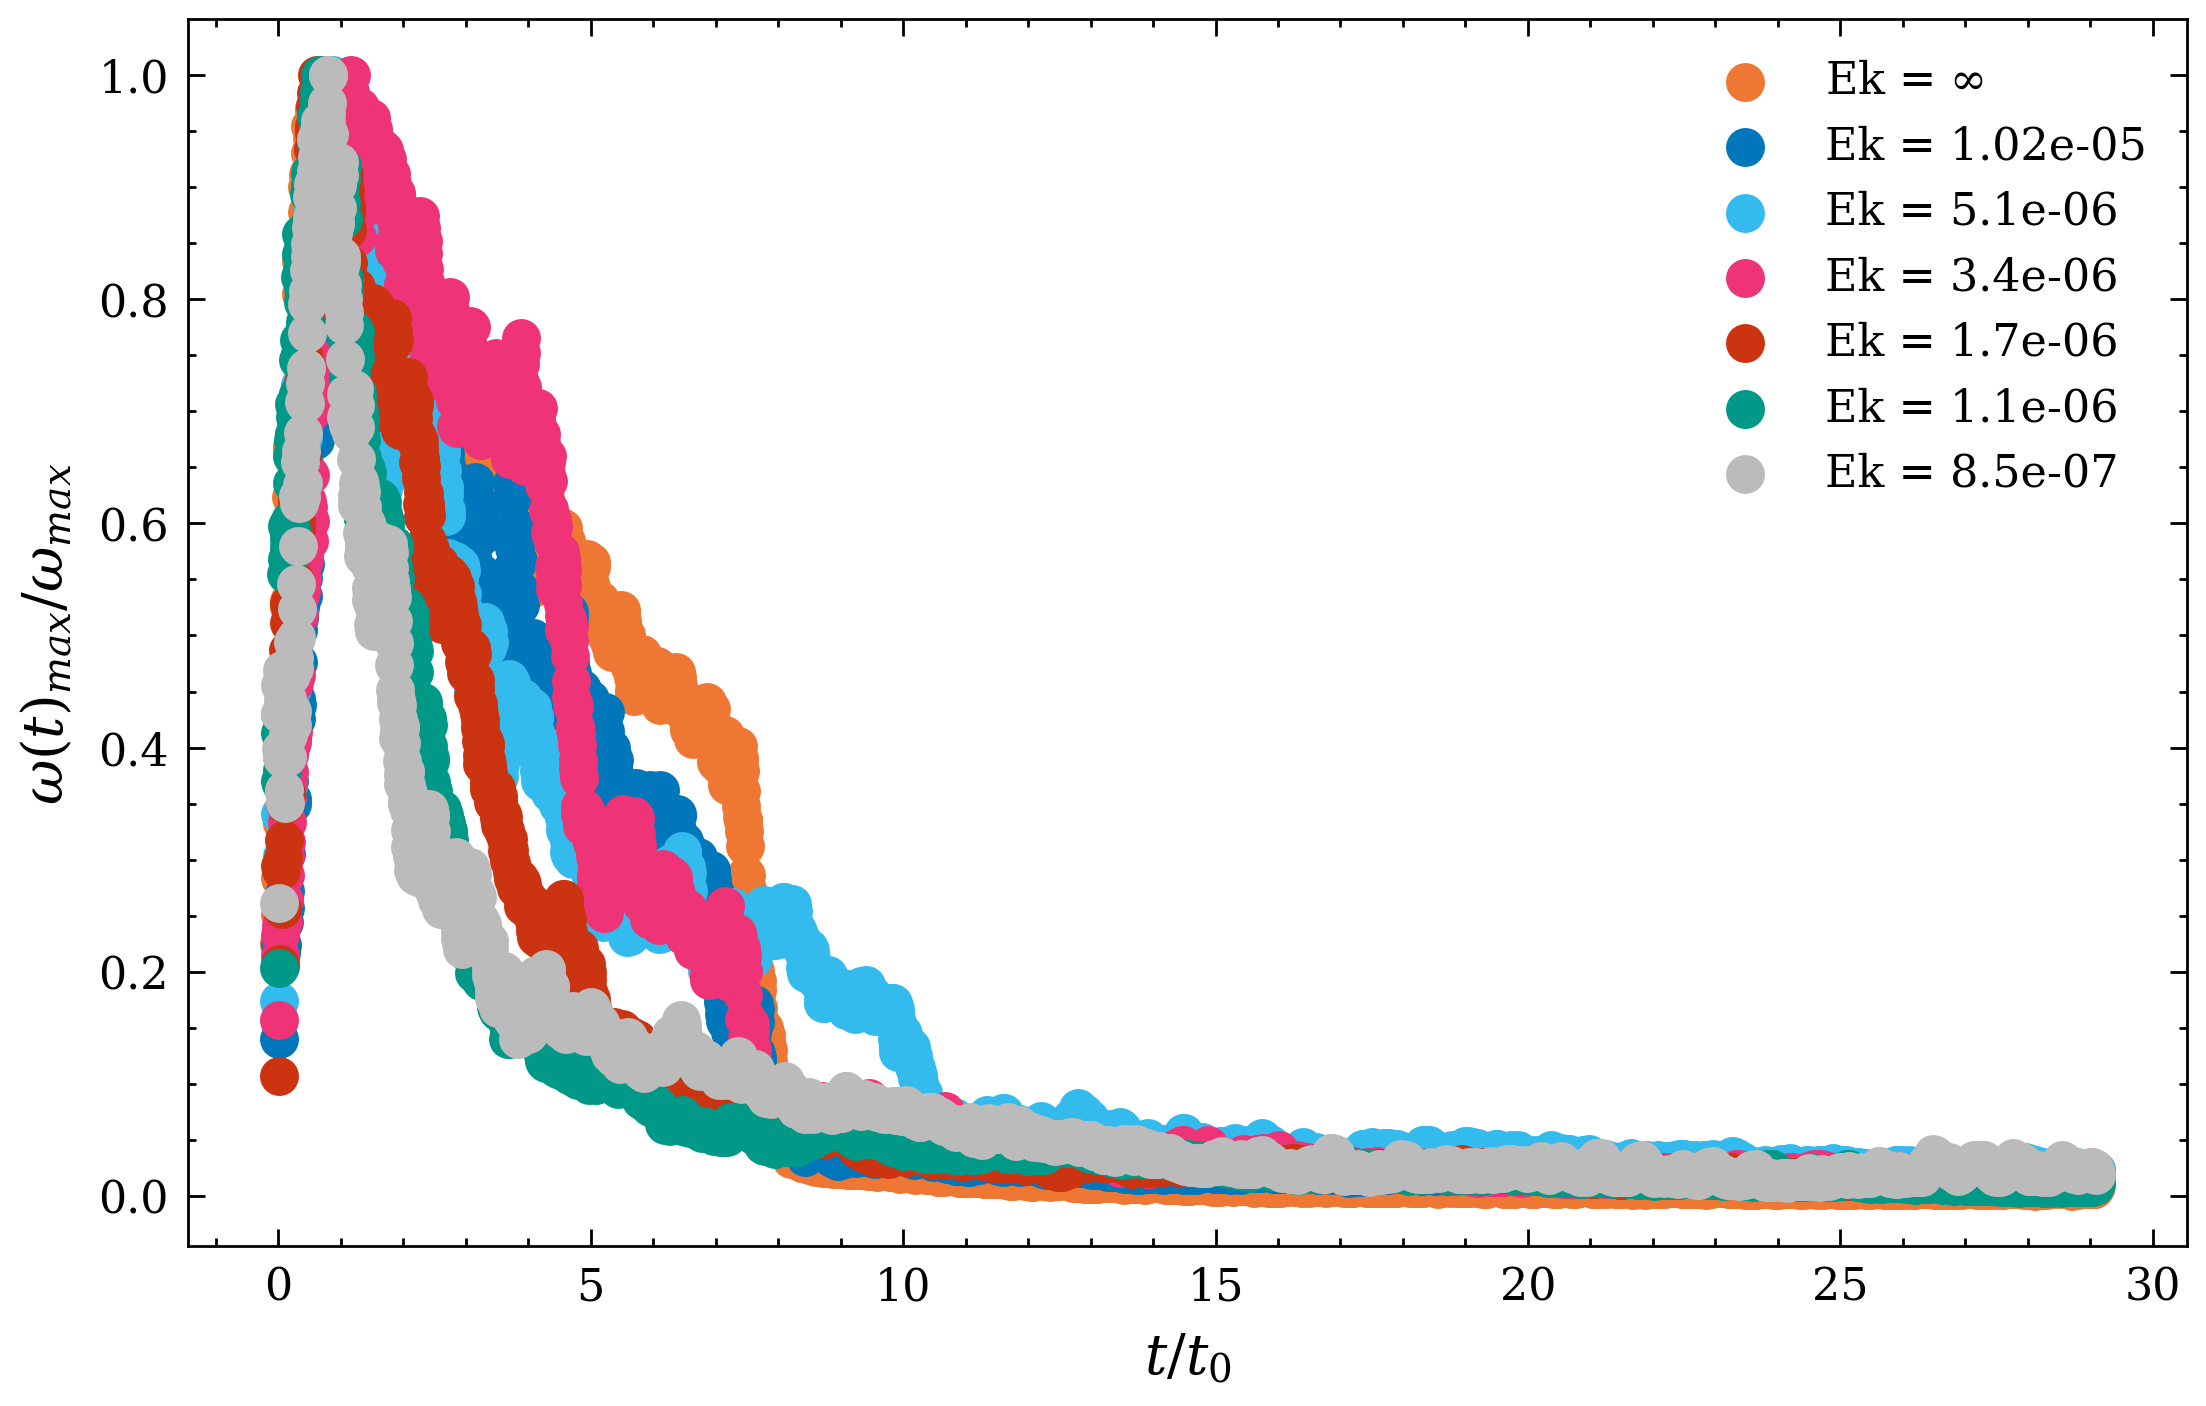

In [7]:
omegaPeak = np.zeros([7, u.shape[0]])
scaling = 1/Time**3

# Eks = [0.0000017, 0.0000011, 0.00000085]
Eks = [r'$\infty$', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
for i in range(7):
    for j in range(u.shape[0]):
        omegaPeak[i, j] = np.max(vort[i, j, :, :])
    
    ax.scatter(Time[81:]-8/9, omegaPeak[i, 81:]/np.max(omegaPeak[i, 81:]), label='Ek = {}'.format(Eks[i]))
    # ax.plot(Time-8/9, Circulation[i, :], label='{} RPM'.format(rpms[i]))
# ax.plot(Time[100:]+1, scaling[100:], label=r'$t^{*-3}$', linestyle='--', color='black')

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\omega(t)_{max}/\omega_{max}$')
plt.legend(fontsize=8)

In [8]:
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
print(u.shape)
edge_r = 119
edge_l = 30 

# svul0  = oj.sum_Vorticity(u[:,20:,:30], v [:,20:,:30]) +  oj.sum_Vorticity( u [:,20:,119:], v [:, 20:, 119:])
svul0  = oj.sum_Vorticity(u[:,:40,45:], v [:,:40,45:]) +  oj.sum_Vorticity( u [:,109:,45:], v[:,109:,45:])



(2699, 149, 239)


0
1
2
3
6
9
12


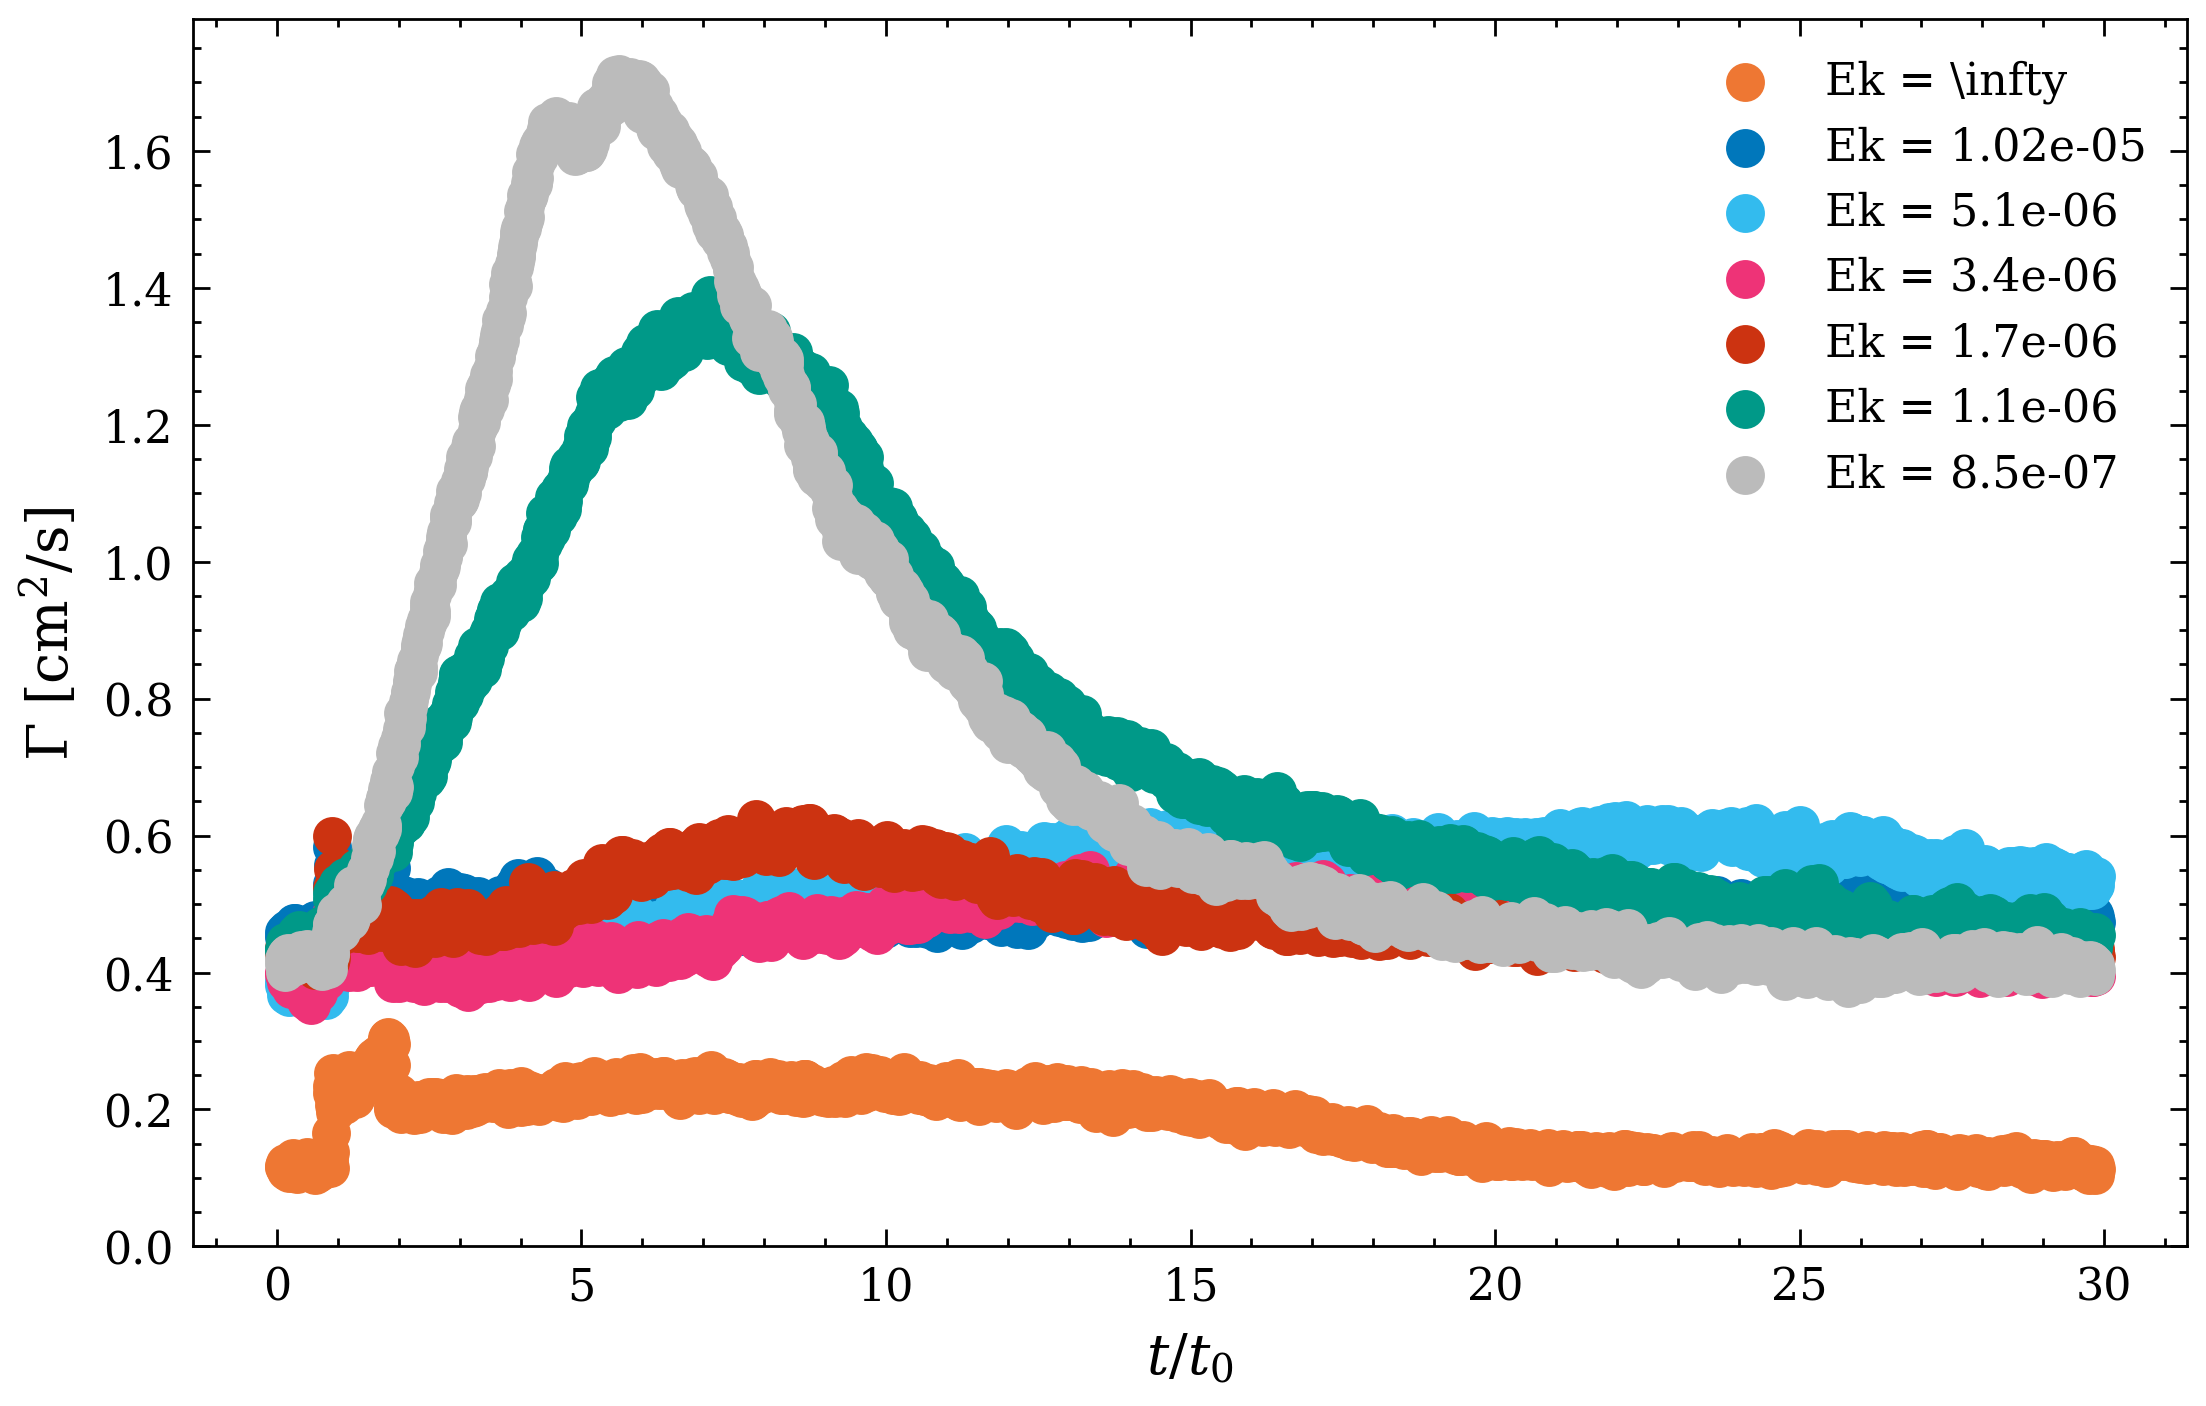

In [9]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
Eks = [r'\infty', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
for i in range(7):
    vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    # svul0  = oj.sum_Vorticity(u[:,:40,45:], v [:,:40,45:]) +  oj.sum_Vorticity( u [:,109:,45:], v[:,109:,45:])
    # ax.plot(Time, svul0[:]-0.4 , label = "Ek = {}".format(Eks[i]))
    svul0  = oj.sum_Vorticity(u[:,:30,45:], v [:,:30,45:]) +  oj.sum_Vorticity( u [:,119:,45:], v[:,119:,45:])
    ax.scatter(Time[10:-10], svul0[10:-10]-0.3 , label = "Ek = {}".format(Eks[i]))
    print(rpms[i])

ax.set_xlabel(r"$t/t_{0}$")
ax.set_ylabel('$\Gamma$ [cm$^2$/s]')
# plt.title("Circulation at large r 50/50")
ax.set_ylim(0)
plt.legend(fontsize=8)

# fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(5.5, 3.5))
# ax2.quiver(u[500,:40,45:], v[500,:40,45:])
# ax3.quiver(u[500,119:,45:], v[500,119:,45:])

plotting peak $\omega$ for rings with the same Ro

In [10]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
vels = h5file['Narrow']['U100']['L100']['RPM0']
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u1 = vels[:,:,:,0]
v1 = vels[:,:,:,1] 
vort1, vort_gauss1 = oj.calculate_vorticity(u1, v1)
VortLocMax1, VortLocMin1 = oj.vorticityPeakTracking_inter(u1[:,:,:], v1[:,:,:])
VortLocMin1[:,0] = np.subtract(VortLocMin1[:,0], int(u.shape[1]/2))
VortLocMax1[:,0] = np.subtract(VortLocMax1[:,0], int(u.shape[1]/2))
r_factor = u.shape[1]/(2*r_nd[-1])
VortLocMax1[:,1], VortLocMax1[:,0] = VortLocMax1[:,1]/r_factor-1, VortLocMax1[:,0]/r_factor

vels = h5file['Narrow']['U50']['L50']['RPM0']
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u2 = vels[:,:,:,0]
v2 = vels[:,:,:,1] 
vort2, vort_gauss2 = oj.calculate_vorticity(u2, v2)
vort1, vort_gauss1 = oj.calculate_vorticity(u1, v1)
VortLocMax2, VortLocMin2 = oj.vorticityPeakTracking_inter(u2[:,:,:], v2[:,:,:])
VortLocMin2[:,0] = np.subtract(VortLocMin2[:,0], int(u.shape[1]/2))
VortLocMax2[:,0] = np.subtract(VortLocMax2[:,0], int(u.shape[1]/2))
VortLocMax2[:,1], VortLocMax2[:,0] = VortLocMax2[:,1]/r_factor-1, VortLocMax2[:,0]/r_factor

omegaPeak1 = np.zeros([u.shape[0]])
omegaPeak2 = np.zeros([u.shape[0]])
scaling = 1/Time**2

for i in range(u.shape[0]):
    omegaPeak1[i] = np.max(vort1[i,:, :])
    omegaPeak2[i] = np.max(vort2[i,:, :])




/var/folders/3b/wm5n0kv12hbfldn7fhkv1d280000gn/T/ipykernel_34599/3835366409.py:28: RuntimeWarning: divide by zero encountered in true_divide
  scaling = 1/Time**2


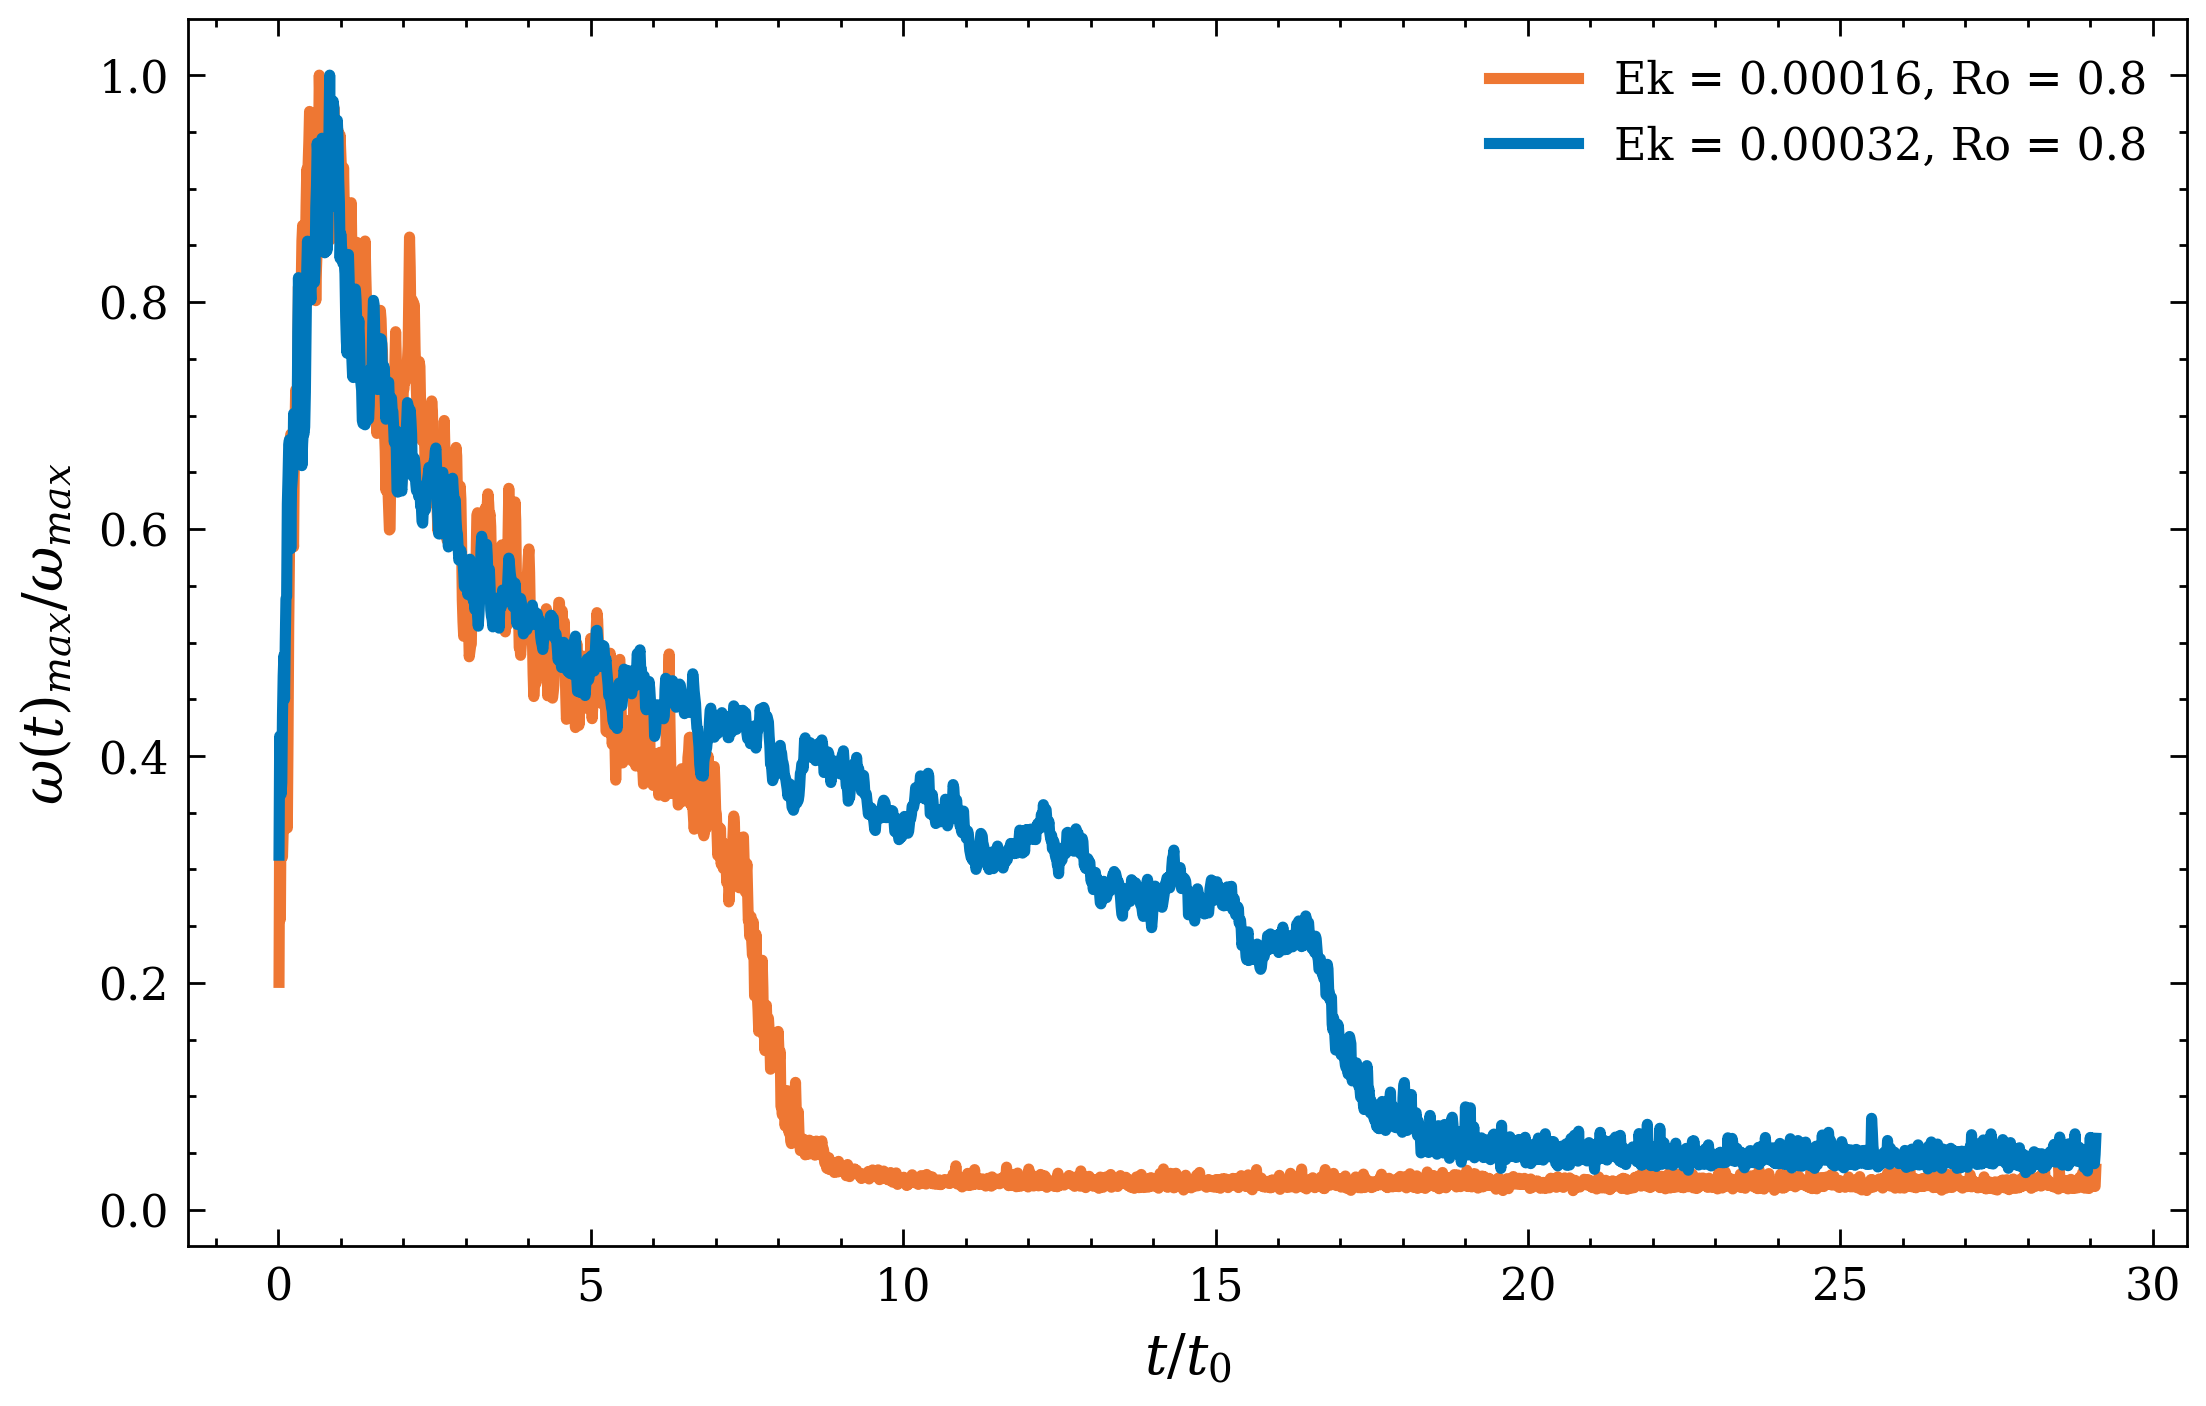

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.plot(Time[81:]-8/9, omegaPeak1[81:]/np.max(omegaPeak1),     label=f'Ek = {(round(oj.Ek(12), 5))}, Ro = {(round(oj.Ro(0.1, 12), 2))}')
ax.plot((Time[81:]-8/9), omegaPeak2[81:]/np.max(omegaPeak2), label=f'Ek = {(round(oj.Ek(6), 5))}, Ro = {(round(oj.Ro(0.05, 6), 2))}')
# ax.plot(Time[50:]+1, scaling[50:]*0.5, label=r'$t^{*-3}$', linestyle='--', color='black')

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\omega(t)_{max}/\omega_{max}$')
plt.legend(fontsize=8)

# f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax2.plot(Time[81:]-8/9, VortLocMax1[81:,0], label='Max Vorticity 1')
# ax2.plot(Time[81:]-8/9, VortLocMax2[81:,0], label='Max Vorticity 2')

# f3, ax3 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax3.plot( Time[81:]-8/9,    omegaPeak1[81:]/VortLocMax1[81:, 0], label='Ek = {}'.format(round(oj.Ek(2), 5)))
# ax3.plot((Time[81:]-8/9)/2, omegaPeak2[81:]/VortLocMax2[81:, 0], label='Ek = {}'.format(round(oj.Ek(1), 5)))
# ax3.plot(Time[50:]+1, scaling[50:]*0.5, label=r'$t^{*-3}$', linestyle='--', color='black')
plt.legend(fontsize=8)

Manual Length Test
Old: 25, 50, 100, 240

New: 75, 125, 150, 175, 200, 225

In [12]:
h5file = h5py.File('/Volumes/HLS_0D0/H5/LengthTest.h5', 'r')

# OLD FILE
# lensOLD = [25, 50, 100, 240]
lensOLD = [25, 50, 75, 100, 125, 150, 175, 200, 225, 240]
CirculationOLD = np.zeros([len(lensOLD), u.shape[0]])


for i in range(len(lensOLD)):
    print(lensOLD[i])
    vels = h5file['Narrow']['U100']['L{}'.format(lensOLD[i])]['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    CirculationOLD[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])

Time = oj.frames_to_seconds(u, v, 90)


#NEW FILE
h5file = h5py.File('/Volumes/HLS_0D0/H5/LengthTestNEW.h5', 'r')

# OLD FILE
# lensNEW = [75, 125, 150, 175, 200, 225]
lensNEW = [25, 50, 75, 100, 125, 150, 175, 200, 225, 240]
CirculationNEW = np.zeros([len(lensNEW), u.shape[0]])


for i in range(len(lensNEW)):
    print(lensNEW[i])
    vels = h5file['Narrow']['U100']['L{}'.format(lensNEW[i])]['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    CirculationNEW[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])

25
50
75
100
125
150
175
200
225
240
25
50
75
100
125
150
175
200
225
240


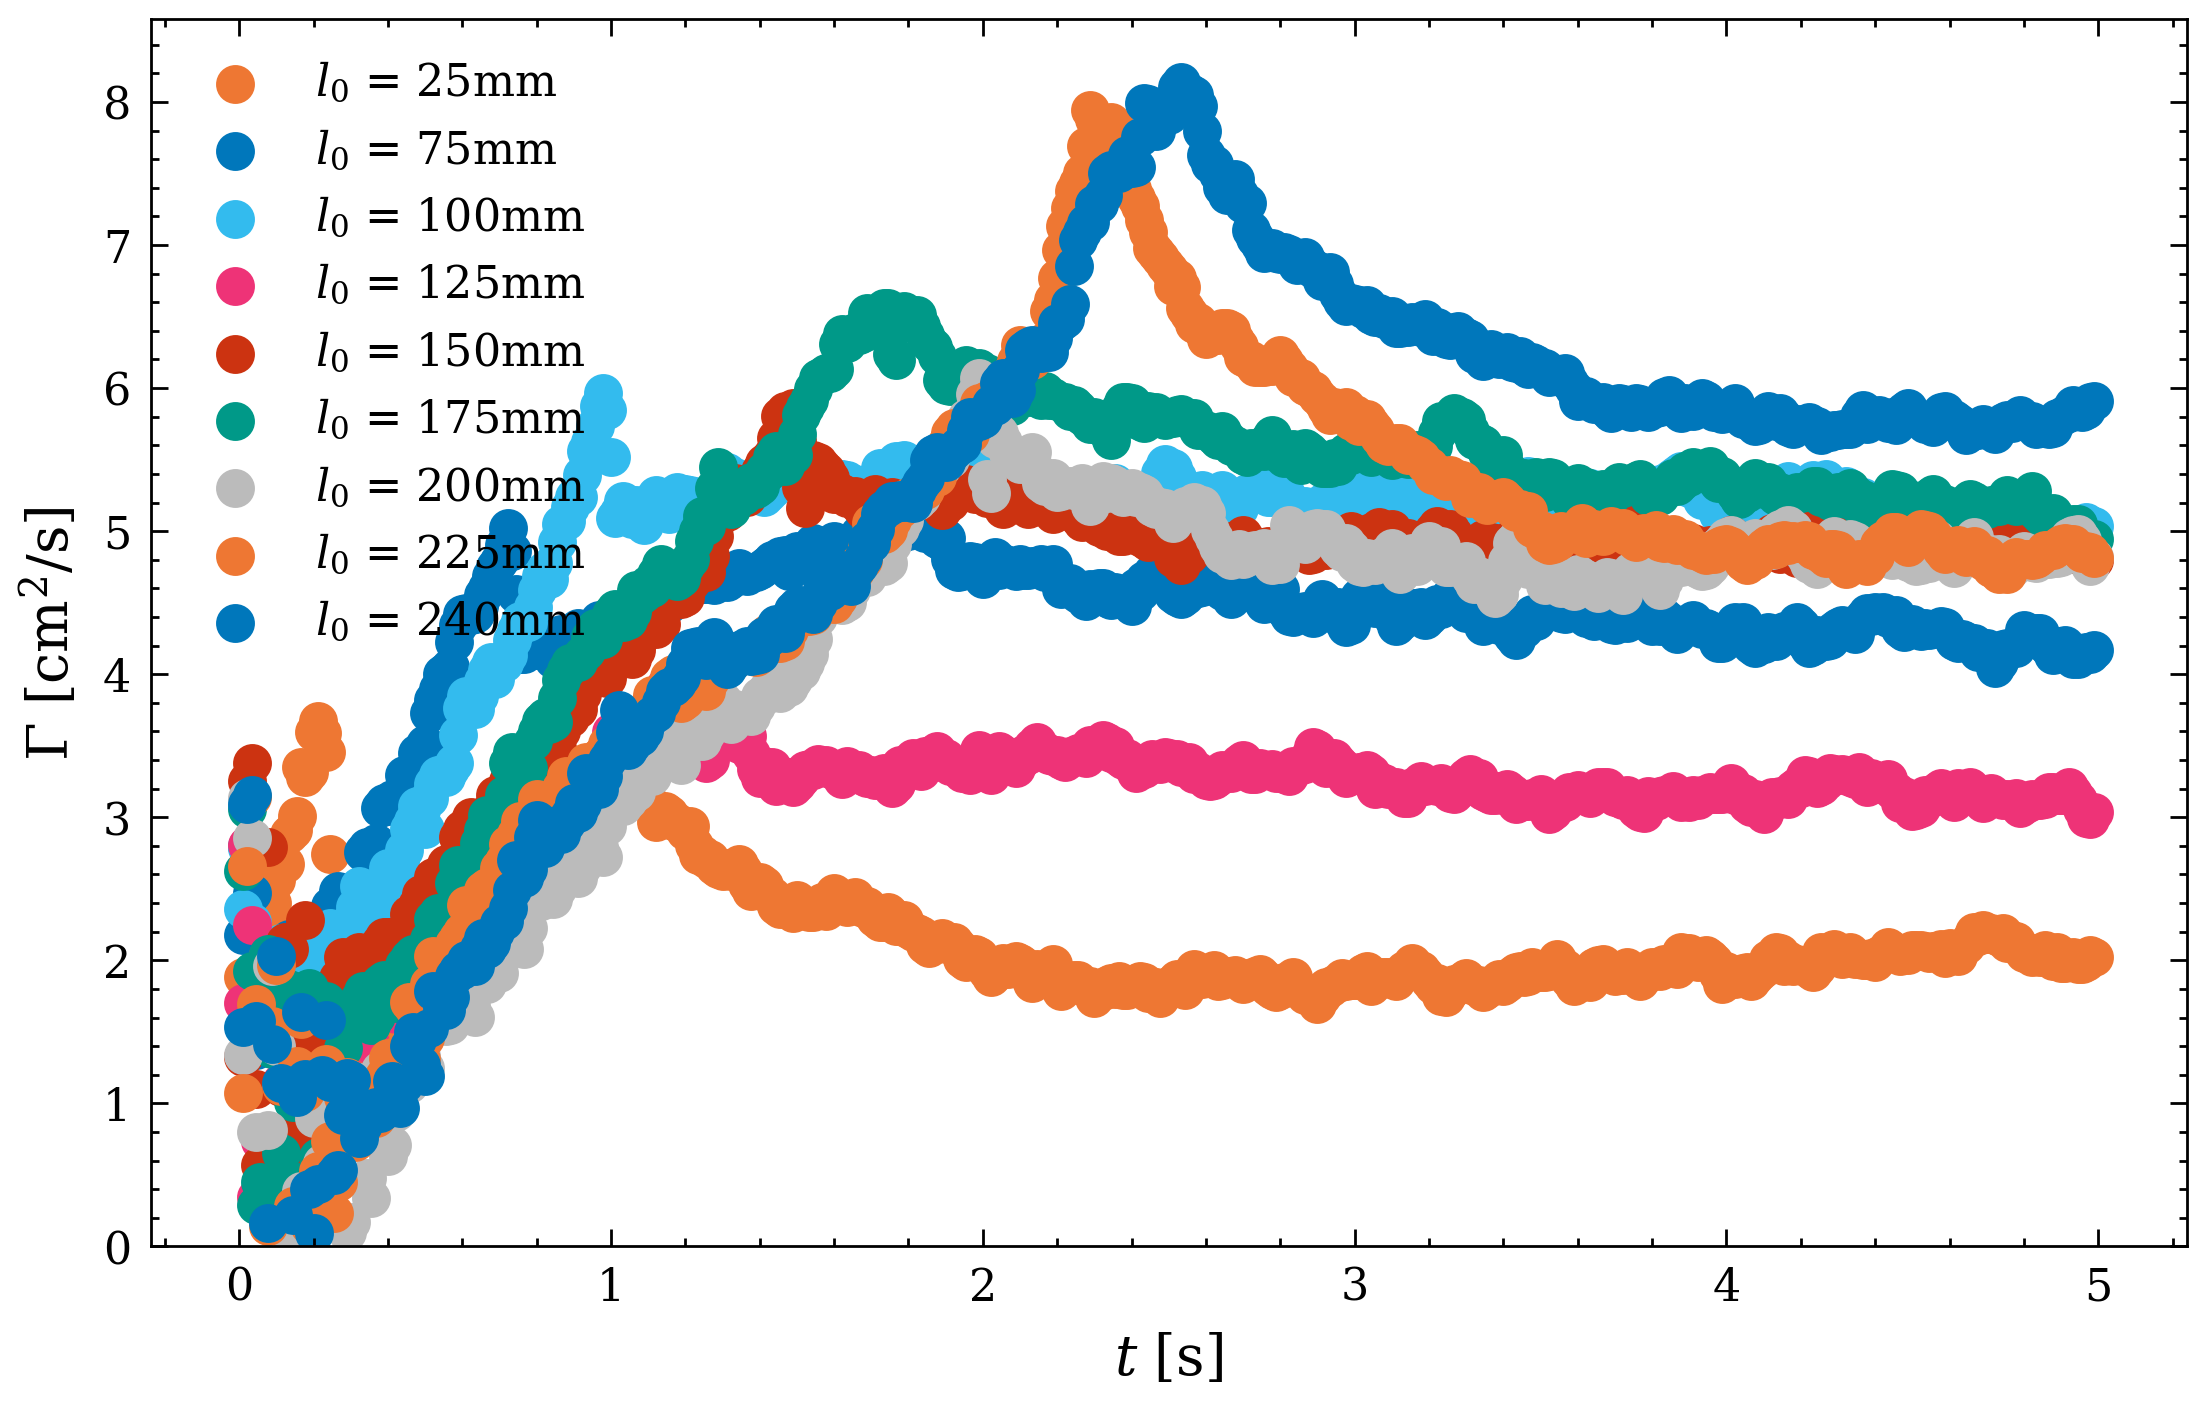

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[0, start_frame:end_frame]-4, label=r'$l_{0}$ = 25mm ')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[1, start_frame:end_frame], label=r'$l_{0}$ = 50mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[2, start_frame:end_frame]-4, label=r'$l_{0}$ = 75mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[3, start_frame:end_frame]-4, label=r'$l_{0}$ = 100mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[4, start_frame:end_frame]-4, label=r'$l_{0}$ = 125mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[5, start_frame:end_frame]-4, label=r'$l_{0}$ = 150mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[6, start_frame:end_frame]-4, label=r'$l_{0}$ = 175mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[7, start_frame:end_frame]-4, label=r'$l_{0}$ = 200mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[8, start_frame:end_frame]-4, label=r'$l_{0}$ = 225mm')
ax.scatter(Time[start_frame:end_frame]-8/9, CirculationNEW[9, start_frame:end_frame]-4, label=r'$l_{0}$ = 240mm')

# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[0, start_frame:end_frame], label=r'$l_{0}$ = 25mm ')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[1, start_frame:end_frame]-4, label=r'$l_{0}$ = 50mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[2, start_frame:end_frame], label=r'$l_{0}$ = 75mm')
# # ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[3, start_frame:end_frame], label=r'$l_{0}$ = 100mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[4, start_frame:end_frame], label=r'$l_{0}$ = 125mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[5, start_frame:end_frame], label=r'$l_{0}$ = 150mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[6, start_frame:end_frame], label=r'$l_{0}$ = 175mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[7, start_frame:end_frame], label=r'$l_{0}$ = 200mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[8, start_frame:end_frame], label=r'$l_{0}$ = 225mm')
# ax.scatter(Time[start_frame:end_frame]-8/9, CirculationOLD[9, start_frame:end_frame], label=r'$l_{0}$ = 240mm')
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

regular rings:

In [14]:
#NEW FILE
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLS.h5', 'r')

# OLD FILE
lens = [50, 100]
inj = [50, 100]
CirculationNEW = np.zeros([len(lens), u.shape[0]])


for i in range(len(lens)):
    print(lens[i])
    for j in range(len(inj)):
        print(inj[j])
        vels = h5file['Narrow']['U{}'.format(inj[j])]['L{}'.format(lens[i])]['RPM0']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        u, v = oj.scaleVelNozzle(u, v, 90)
        Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])


50
50
100
100
50
100


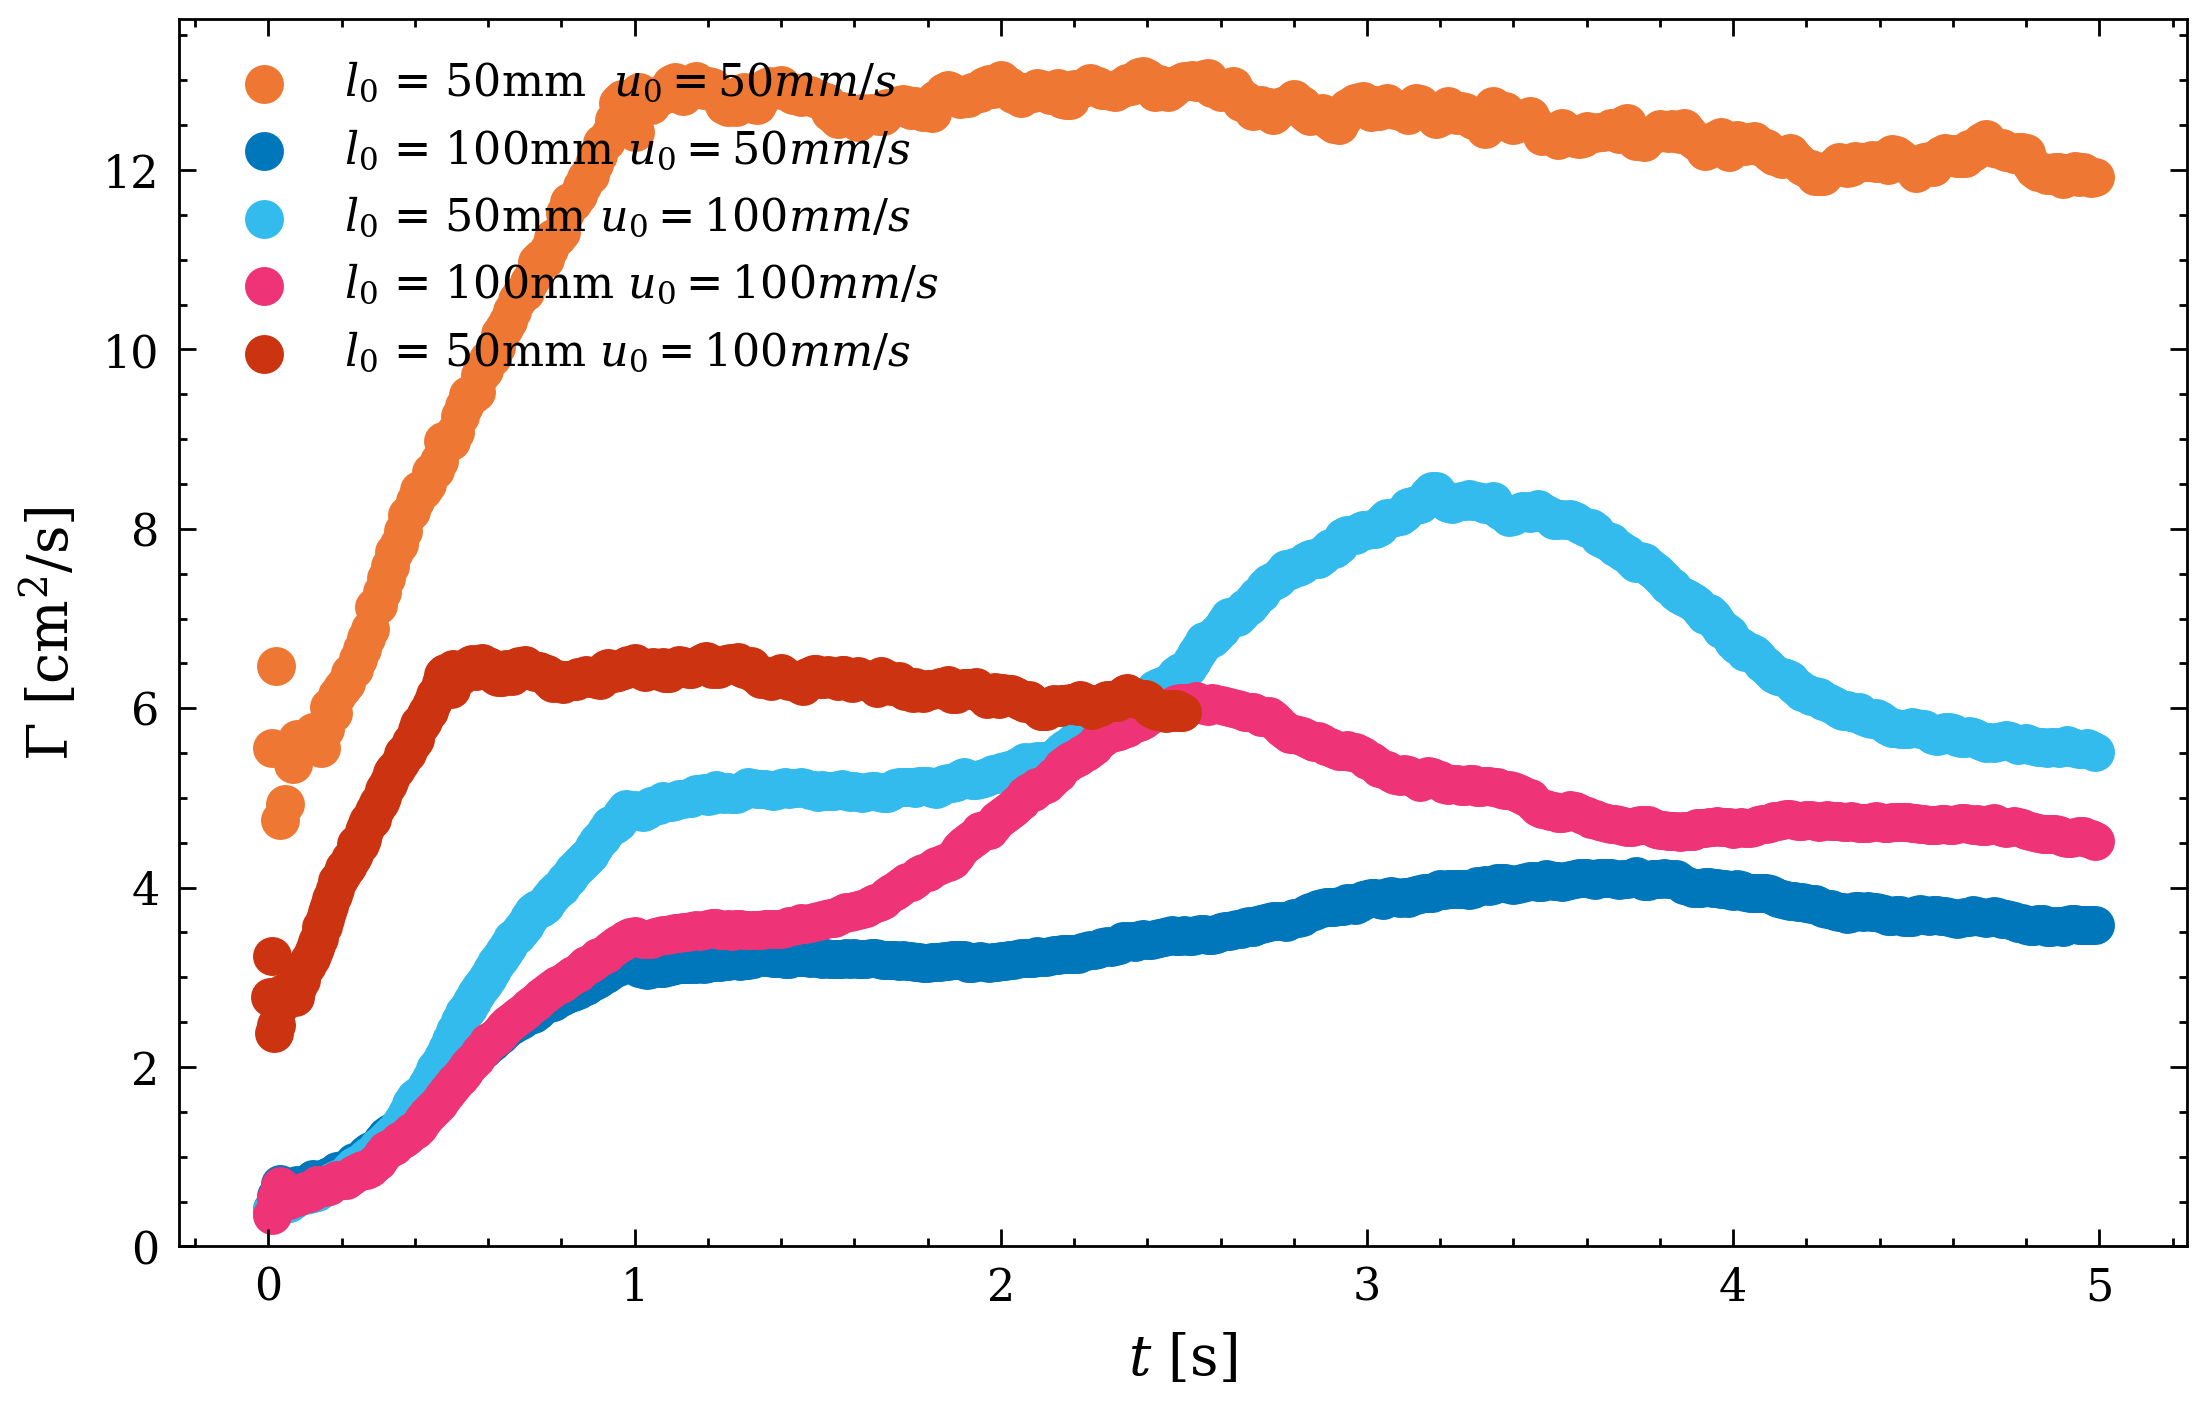

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[1, start_frame:end_frame], label=r'$l_{0}$ = 50mm  $u_{0} = 50mm/s$')
ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[2, start_frame:end_frame], label=r'$l_{0}$ = 100mm $u_{0} = 50mm/s$')
ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[3, start_frame:end_frame], label=r'$l_{0}$ = 50mm $u_{0} = 100mm/s$')
ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[4, start_frame:end_frame], label=r'$l_{0}$ = 100mm $u_{0} = 100mm/s$')
ax.scatter((Time[start_frame:end_frame]-8/9)/2, Circulation[1, start_frame:end_frame]/2, label=r'$l_{0}$ = 50mm $u_{0} = 100mm/s$')
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


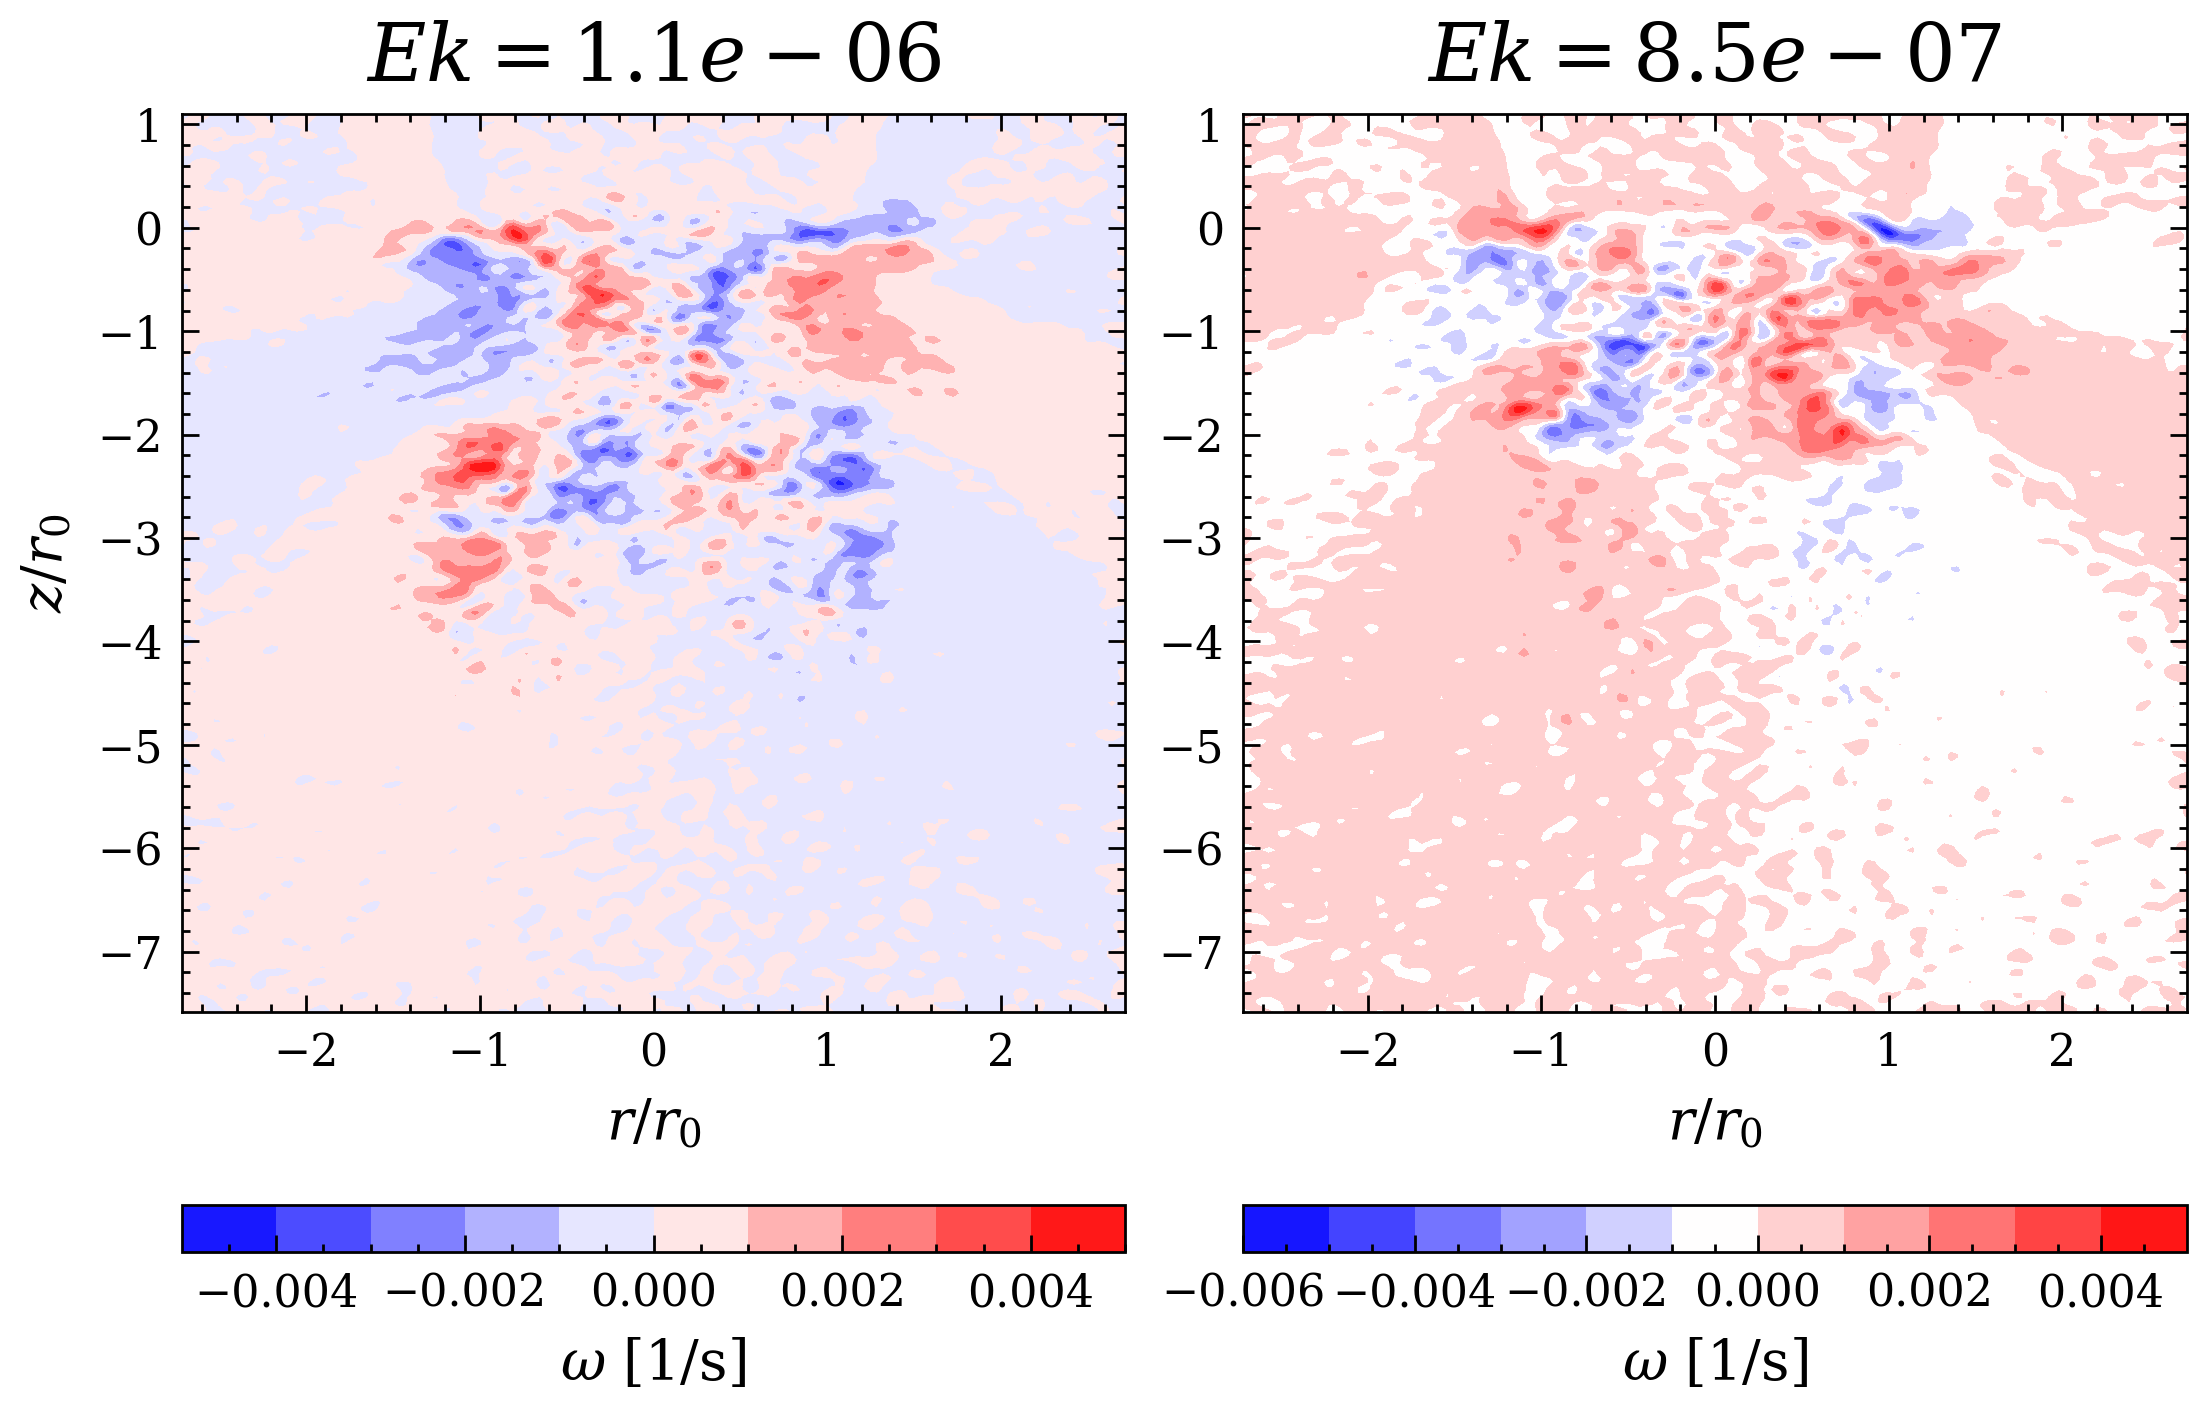

: 

In [ ]:
# Descriptive contoours

#NEW FILE
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLS.h5', 'r')


vels = h5file['Narrow']['U100']['L100']['RPM9']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u9, v9 = oj.scaleVelNozzle(u, v, 90)
vort9, vort_gauss9 = oj.calculate_vorticity(u9, v9)


vels = h5file['Narrow']['U100']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u12, v12 = oj.scaleVelNozzle(u, v, 90)
vort12, vort_gauss12 = oj.calculate_vorticity(u12, v12)
# 0.0000011, 0.00000085



fig, ax = plt.subplots(1, 2, figsize=(5.5, 3.5))
ax[0].set_title(rf'$Ek = 1.1e-06$')
c = ax[0].contourf(r_nd, -z_nd, np.rot90(vort_gauss9[351,:,:], 3), 10, cmap='bwr')
fig.colorbar(c, ax=ax[0], location='bottom', label = r'$\omega$ [1/s]')
ax[1].set_title(rf'$Ek = 8.5e-07$')
c = ax[1].contourf(r_nd, -z_nd, np.rot90(vort_gauss12[306,:,:], 3), 10, cmap='bwr')
fig.colorbar(c, ax=ax[1], location='bottom', label = r'$\omega$ [1/s]')
ax[0].set_xlabel(r"$r/r_{0}$")
ax[0].set_ylabel(r"$z/r_{0}$")
ax[1].set_xlabel(r"$r/r_{0}$")
plt.legend(fontsize=8)